### 1. Wstęp

In [115]:
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [116]:
file_path = kagglehub.dataset_download('camnugent/california-housing-prices')
print(f'File path: {file_path}')

files = os.listdir(file_path)
print(files)

File path: C:\Users\patry\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1
['housing.csv']


In [117]:
csv_path = os.path.join(file_path, files[0])
print(csv_path)

C:\Users\patry\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1\housing.csv


In [118]:
data = pd.read_csv(csv_path)
print(data.shape)
data.info()

(20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### 2. Preprocessing

In [119]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Co muszę najpierw zrobić?
- sprawdzić ile jest pustych komórek
  - sprawdzić które kolumny zawierają ich najwięcej i zdecydować co z nimi zrobić
- sprawdzić które kolumny zawierają obiekty zamiast cyfr
  - zamienić te obiekty na one hot encoding
- EDA (wykresy)
- wybór algorytmu i budowa modelu

In [120]:
columns_with_miss_val = data.isnull().sum()
col_with_miss_val_percent = ((columns_with_miss_val[columns_with_miss_val > 0] / data.shape[0]) * 100).sort_values(ascending=False)
print(col_with_miss_val_percent)

total_bedrooms    1.002907
dtype: float64


Przy tak małej ilości brakujących danych można przemyśleć usunięcie wierszy z brakującymi wartościami ('*drop*'). Jednak na potrzeby tego ćwiczenia uzupełnię brakujące komórki medianą wartości z pozostałych wierszy.

In [121]:
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)


In [122]:
preprocessor = ColumnTransformer(transformers=[
	('num', SimpleImputer(strategy='median'), ['total_bedrooms'])
], remainder='passthrough', verbose_feature_names_out=False)

preprocessor.set_output(transform='pandas')

X_train_imputed = preprocessor.fit_transform(X_train)
X_test_imputed = preprocessor.transform(X_test)

print(X_train_imputed.isnull().sum())
print(X_test_imputed.isnull().sum())

total_bedrooms        0
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64
total_bedrooms        0
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64


Wiedząc, że tylko kolumna '*ocean_proximity*' zawiera obiekty zamiast liczb, zastosuję na niej technikę **One Hot Encoding** w celu zamiany na wartości liczbowe.

In [123]:
categorical_cols = [col_name for col_name in X_train_imputed.columns if X_train_imputed[col_name].dtype == 'object']
print(X_train_imputed[categorical_cols].nunique())
print('----------------')
print(X_train_imputed[categorical_cols].value_counts())

ocean_proximity    5
dtype: int64
----------------
ocean_proximity
<1H OCEAN          7309
INLAND             5287
NEAR OCEAN         2092
NEAR BAY           1820
ISLAND                4
Name: count, dtype: int64


Ze względu na dosyć małą liczbę (5) unikalnych wartości w kolumnie '*ocean_proximity*', mogę śmiało zastosować **One Hot Encoding**.

In [194]:
my_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

oh_cols_train = my_encoder.fit_transform(X_train_imputed[categorical_cols])
oh_cols_test = my_encoder.transform(X_test_imputed[categorical_cols])

X_train_final = pd.concat([X_train_imputed.drop(categorical_cols, axis=1), oh_cols_train], axis=1)
X_test_final = pd.concat([X_test_imputed.drop(categorical_cols, axis=1), oh_cols_test], axis=1)

In [195]:
X_train_final['rooms_per_household'] = X_train_final['total_rooms'] / X_train_final['households']
X_test_final['rooms_per_household'] = X_test_final['total_rooms'] / X_test_final['households']

X_train_final.head()

,total_bedrooms,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household
19464,476.0,-120.97,37.69,16.0,2793.0,1279.0,477.0,3.4667,0.0,1.0,0.0,0.0,0.0,5.855346
13265,341.0,-117.65,34.10,30.0,1461.0,1014.0,345.0,2.4667,0.0,1.0,0.0,0.0,0.0,4.234783
5829,468.0,-118.30,34.19,52.0,2962.0,1364.0,466.0,4.9042,1.0,0.0,0.0,0.0,0.0,6.356223
5111,356.0,-118.31,33.96,48.0,2015.0,1020.0,338.0,4.0625,1.0,0.0,0.0,0.0,0.0,5.961538
19761,340.0,-122.17,40.11,24.0,1631.0,1042.0,333.0,1.7708,0.0,1.0,0.0,0.0,0.0,4.897898


### 3. EDA

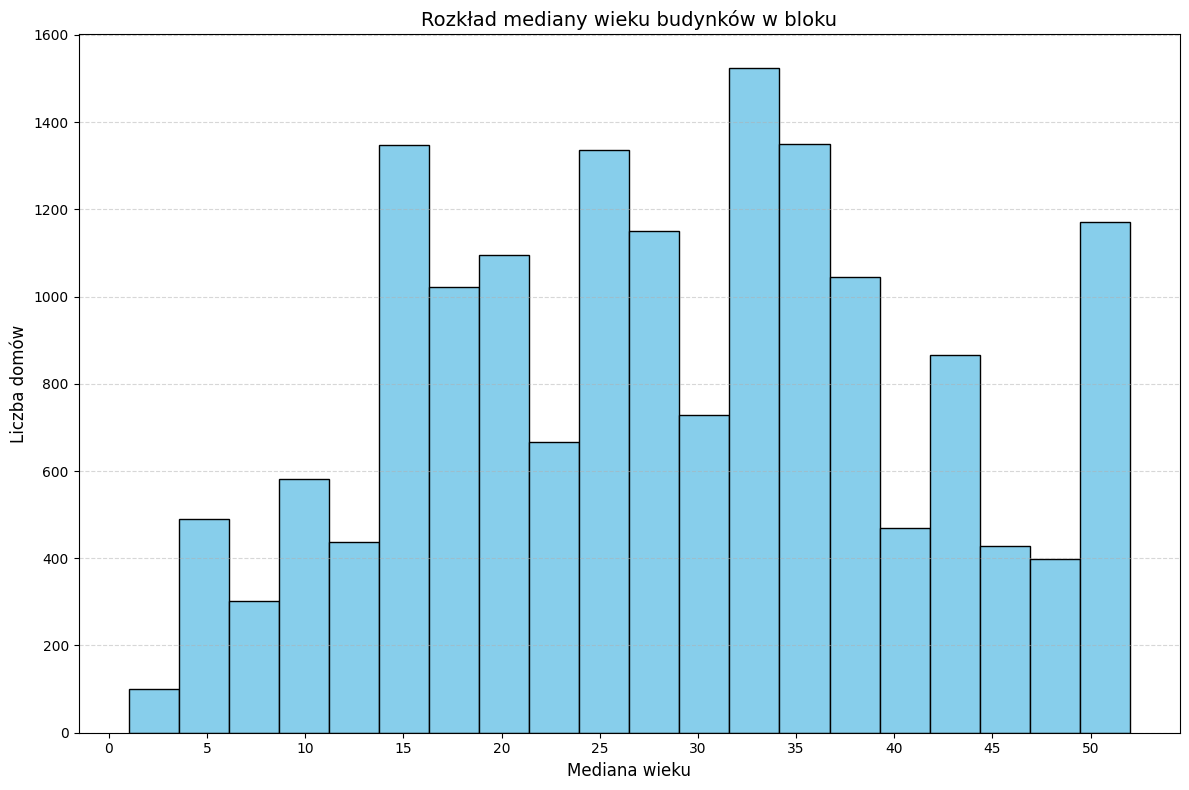

In [180]:
plt.figure(figsize=(12, 8))

plt.hist(X_train_final['housing_median_age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Rozkład mediany wieku budynków w bloku', fontsize=14)
plt.xlabel('Mediana wieku', fontsize=12)
plt.xticks(np.arange(0, 52, 5))
plt.ylabel('Liczba domów', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

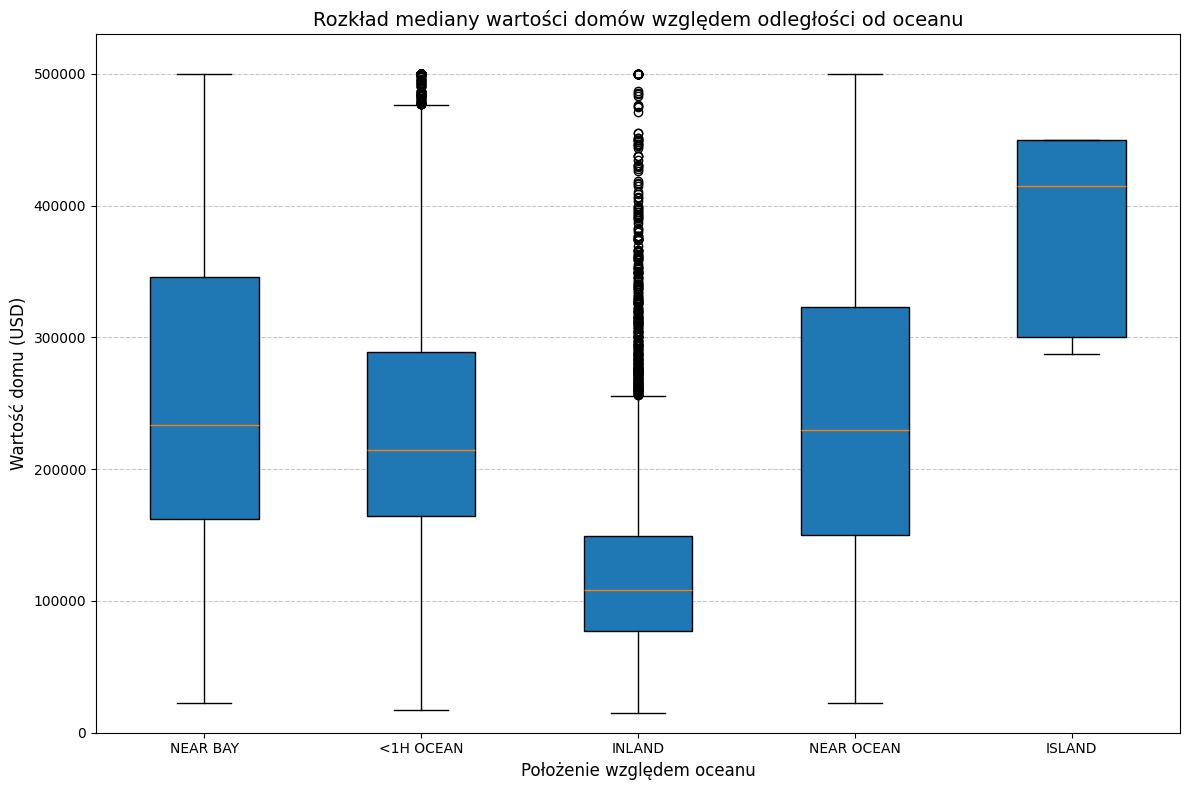

In [189]:
categories = data['ocean_proximity'].unique()
data_to_plot = [data[data['ocean_proximity'] == cat]['median_house_value'] for cat in categories]

plt.figure(figsize=(12, 8))

plt.boxplot(data_to_plot, tick_labels=categories, patch_artist=True)
plt.title('Rozkład mediany wartości domów względem odległości od oceanu', fontsize=14)
plt.xlabel('Położenie względem oceanu', fontsize=12)
plt.ylabel('Wartość domu (USD)', fontsize=12)
plt.ylim(0, 530000)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

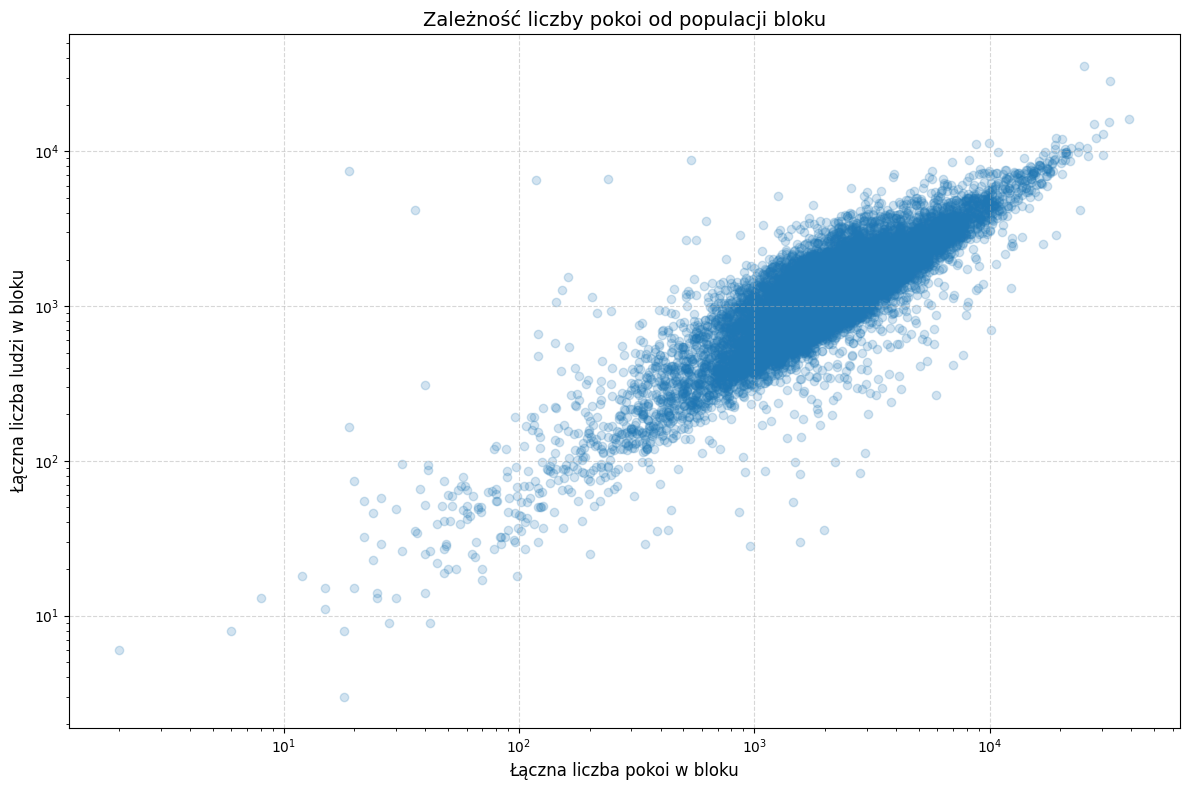

In [190]:
plt.figure(figsize=(12, 8))

plt.scatter(X_train_final['total_rooms'], X_train_final['population'], alpha=0.2)
plt.title('Zależność liczby pokoi od populacji bloku', fontsize=14)
plt.xlabel('Łączna liczba pokoi w bloku', fontsize=12)
plt.xscale('log')
plt.ylabel('Łączna liczba ludzi w bloku', fontsize=12)
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

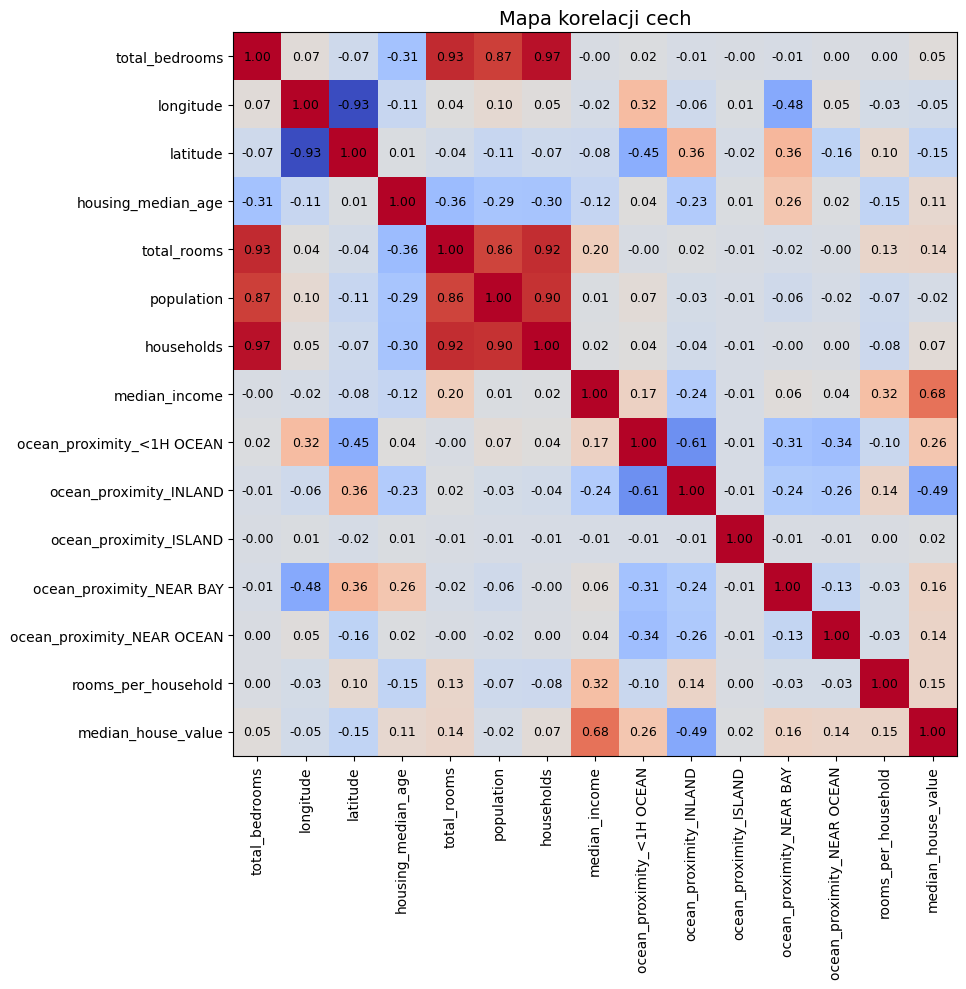

In [216]:
data_for_heatmap = X_train_final.join(y_train)
corr_matrix = data_for_heatmap.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

ticks = np.arange(len(corr_matrix.columns))
plt.xticks(ticks=ticks, labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=ticks, labels=corr_matrix.columns)
plt.title('Mapa korelacji cech', fontsize=14)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()

### 4. Budowanie modelu